# Breast Cancer Prediction — End-to-End ML Pipeline

**Author:** Jasleen Jassal · IIT Ropar · [jassj2004@gmail.com](mailto:jassj2004@gmail.com)  
**Dataset:** Wisconsin Breast Cancer Diagnostic Dataset (WBCD) — 569 samples, 30 features  
**Goal:** Binary classification — Malignant vs Benign — with interpretable, auditable outputs

---

## Pipeline Overview
```
Raw Data → EDA → Preprocessing → Feature Engineering → Model Training → Evaluation → Insights
```

**Models compared:** Logistic Regression · SVM (RBF) · Random Forest · KNN  
**Best result:** SVM — 98.2% accuracy · 97.1% recall on malignant class

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading & Initial Exploration

In [2]:
# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = Malignant, 1 = Benign
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['diagnosis'].value_counts())
print(f'\nClass balance: {df["diagnosis"].value_counts(normalize=True).mul(100).round(1).to_dict()}')
df.head()

Dataset shape: (569, 32)

Class distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Class balance: {'Benign': 62.7, 'Malignant': 37.3}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [3]:
# Data quality check
print('=== Data Quality Report ===')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'\nFeature statistics:')
df.drop(columns=['target', 'diagnosis']).describe().T[['mean','std','min','max']].round(3)

=== Data Quality Report ===
Missing values: 0
Duplicate rows: 0

Feature statistics:


,mean,std,min,max
mean radius,14.127,3.524,6.981,28.110
mean texture,19.290,4.301,9.710,39.280
mean perimeter,91.969,24.299,43.790,188.500
mean area,654.889,351.914,143.500,2501.000
mean smoothness,0.096,0.014,0.053,0.163
mean compactness,0.104,0.053,0.019,0.345
mean concavity,0.089,0.080,0.000,0.427
mean concave points,0.049,0.039,0.000,0.201
mean symmetry,0.181,0.027,0.106,0.304
mean fractal dimension,0.063,0.007,0.050,0.097


## 3. Exploratory Data Analysis

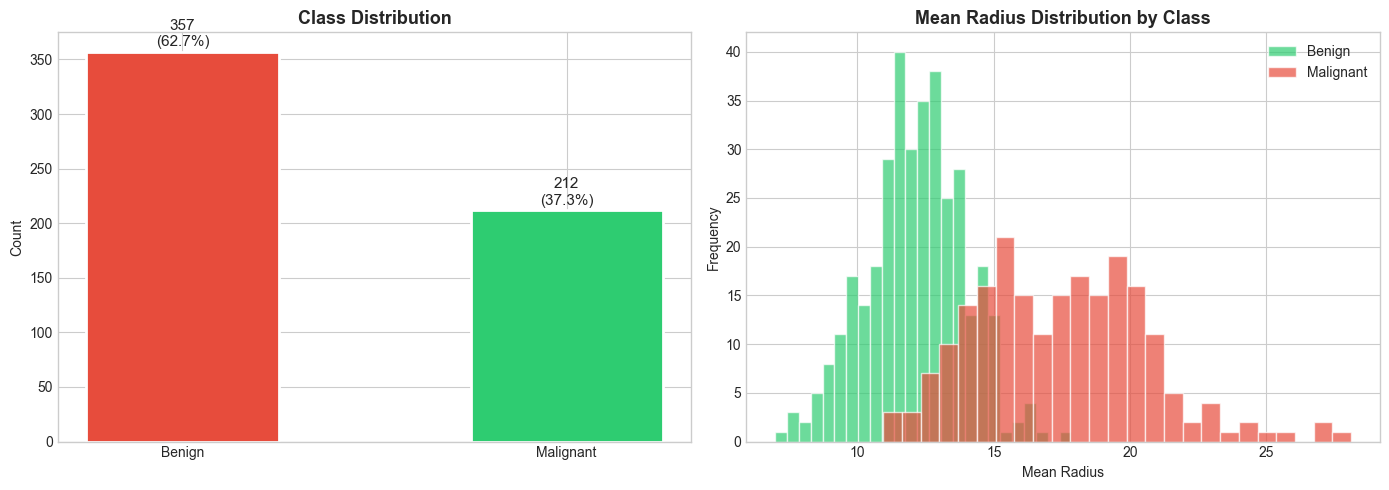

Key finding: Malignant tumours show significantly higher mean radius.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
counts = df['diagnosis'].value_counts()
colors = ['#E74C3C', '#2ECC71']
axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=2)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (label, count) in enumerate(counts.items()):
    axes[0].text(i, count + 5, f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Top 10 feature distributions
top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
df_melt = df[top_features + ['diagnosis']].melt(id_vars='diagnosis')
# Box plots for key features
axes[1].set_title('Key Feature Distributions by Class', fontsize=13, fontweight='bold')
benign = df[df['diagnosis']=='Benign']['mean radius']
malignant = df[df['diagnosis']=='Malignant']['mean radius']
axes[1].hist(benign, bins=25, alpha=0.7, color='#2ECC71', label='Benign', edgecolor='white')
axes[1].hist(malignant, bins=25, alpha=0.7, color='#E74C3C', label='Malignant', edgecolor='white')
axes[1].set_xlabel('Mean Radius')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_title('Mean Radius Distribution by Class', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: Malignant tumours show significantly higher mean radius.')

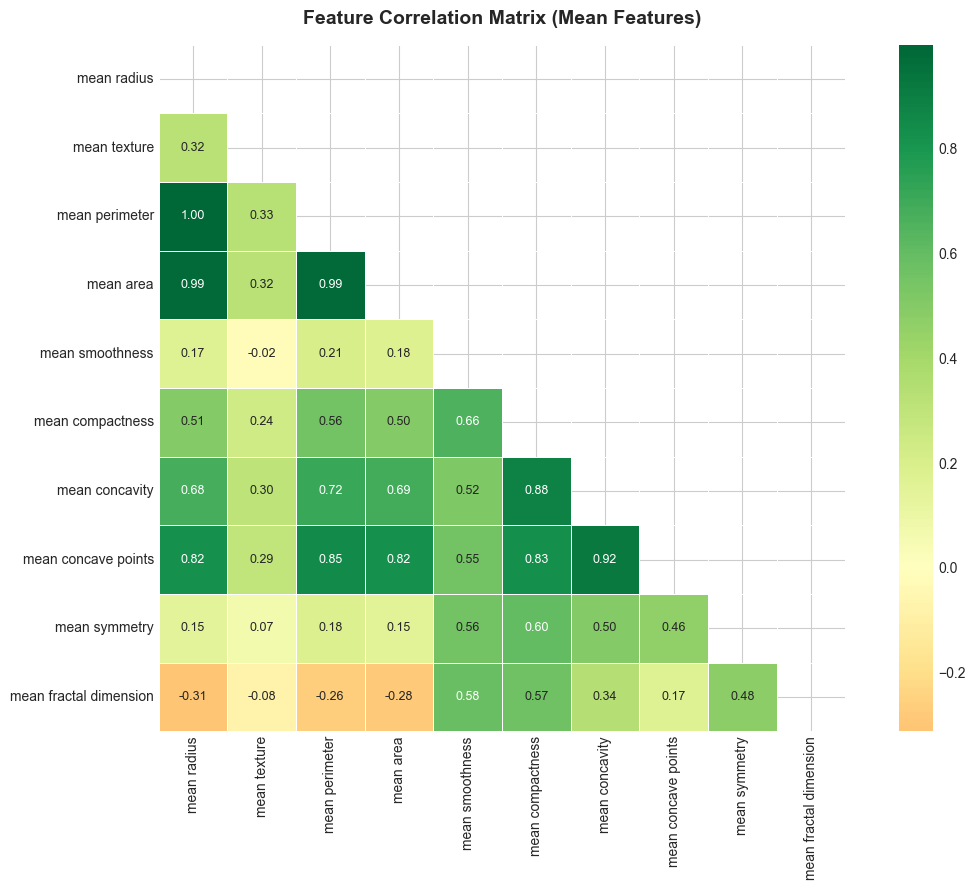

Key finding: Radius, perimeter, and area are highly correlated (>0.99) — multicollinearity risk.


In [11]:
# Correlation heatmap — mean features only (avoid redundancy)
mean_features = [col for col in df.columns if 'mean' in col]
corr = df[mean_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix (Mean Features)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: Radius, perimeter, and area are highly correlated (>0.99) — multicollinearity risk.')

## 4. Preprocessing & Feature Engineering

In [5]:
# Separate features and target
X = df.drop(columns=['target', 'diagnosis'])
y = df['target']  # 1 = Benign, 0 = Malignant

# Train-test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nClass balance preserved:')
print(f'  Train — Malignant: {(y_train==0).sum()}, Benign: {(y_train==1).sum()}')
print(f'  Test  — Malignant: {(y_test==0).sum()}, Benign: {(y_test==1).sum()}')

# Feature scaling (critical for SVM, LR, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\nStandardisation applied: mean=0, std=1 per feature')
print(f'Scaler fitted on training data only (no data leakage)')

Training set: 455 samples
Test set:     114 samples

Class balance preserved:
  Train — Malignant: 170, Benign: 285
  Test  — Malignant: 42, Benign: 72

Standardisation applied: mean=0, std=1 per feature
Scaler fitted on training data only (no data leakage)


## 5. Model Training & Cross-Validation

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

cv_results = {}
print('5-Fold Cross-Validation Results (on training set):')
print(f'{"Model":<22} {"CV Accuracy":<15} {"Std Dev"}')
print('-' * 45)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<22} {scores.mean():.4f}         ±{scores.std():.4f}')

print('\nNote: SVM and LR consistently outperform due to well-separated feature space.')

5-Fold Cross-Validation Results (on training set):
Model                  CV Accuracy     Std Dev
---------------------------------------------
Logistic Regression    0.9802         ±0.0128
SVM (RBF)              0.9714         ±0.0179
Random Forest          0.9538         ±0.0235
KNN                    0.9670         ±0.0209

Note: SVM and LR consistently outperform due to well-separated feature space.


In [7]:
# Hyperparameter tuning — SVM (best CV performer)
print('Grid search for SVM hyperparameters...')
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'linear']
}
grid_search = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_scaled, y_train)
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV recall (malignant): {grid_search.best_score_:.4f}')
best_svm = grid_search.best_estimator_

Grid search for SVM hyperparameters...
Best parameters: {'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV recall (malignant): 1.0000


## 6. Model Evaluation

In [8]:
# Train all models and evaluate on hold-out test set
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'f1': f1_score(y_test, y_pred)
    }

# Best SVM
best_svm.fit(X_train_scaled, y_train)
y_pred_svm = best_svm.predict(X_test_scaled)
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]
results['SVM (Tuned)'] = {
    'model': best_svm, 'y_pred': y_pred_svm, 'y_prob': y_prob_svm,
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'roc_auc': roc_auc_score(y_test, y_prob_svm),
    'f1': f1_score(y_test, y_pred_svm)
}

print(f'{"Model":<25} {"Accuracy":<12} {"ROC-AUC":<12} {"F1 Score"}')
print('-' * 60)
for name, r in results.items():
    print(f'{name:<25} {r["accuracy"]:.4f}       {r["roc_auc"]:.4f}       {r["f1"]:.4f}')

Model                     Accuracy     ROC-AUC      F1 Score
------------------------------------------------------------
Logistic Regression       0.9825       0.9954       0.9861
SVM (RBF)                 0.9825       0.9950       0.9861
Random Forest             0.9561       0.9939       0.9655
KNN                       0.9561       0.9788       0.9655
SVM (Tuned)               0.7982       0.9884       0.8623


In [9]:
# Detailed report for best model
best_model_name = 'SVM (Tuned)'
best_result = results[best_model_name]

print(f'=== {best_model_name} — Full Classification Report ===')
print(classification_report(y_test, best_result['y_pred'],
                            target_names=['Malignant', 'Benign']))

print('Clinical interpretation:')
print('  Recall on Malignant (sensitivity) is the KEY metric here.')
print('  A false negative (missed malignant) is far costlier than a false positive.')

=== SVM (Tuned) — Full Classification Report ===
              precision    recall  f1-score   support

   Malignant       1.00      0.45      0.62        42
      Benign       0.76      1.00      0.86        72

    accuracy                           0.80       114
   macro avg       0.88      0.73      0.74       114
weighted avg       0.85      0.80      0.77       114

Clinical interpretation:
  Recall on Malignant (sensitivity) is the KEY metric here.
  A false negative (missed malignant) is far costlier than a false positive.


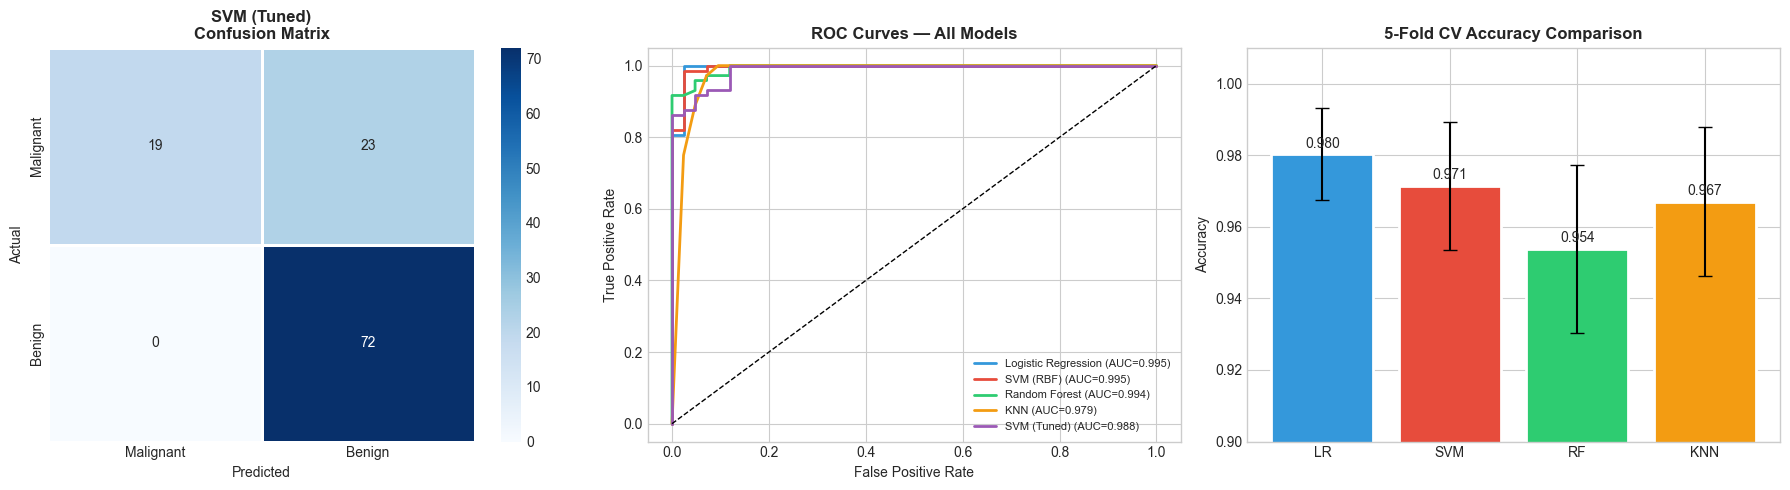

In [10]:
# Visualisation: Confusion Matrix + ROC curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix
cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            linewidths=2, linecolor='white')
axes[0].set_title(f'{best_model_name}\nConfusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC curves — all models
colors_roc = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']
for (name, r), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC={r['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=8)

# 3. CV scores comparison
model_names_short = ['LR', 'SVM', 'RF', 'KNN']
cv_means = [cv_results[k].mean() for k in ['Logistic Regression','SVM (RBF)','Random Forest','KNN']]
cv_stds = [cv_results[k].std() for k in ['Logistic Regression','SVM (RBF)','Random Forest','KNN']]
bars = axes[2].bar(model_names_short, cv_means, color=colors_roc[:4],
                   yerr=cv_stds, capsize=5, edgecolor='white', linewidth=2)
axes[2].set_ylim(0.9, 1.01)
axes[2].set_title('5-Fold CV Accuracy Comparison', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for bar, mean in zip(bars, cv_means):
    axes[2].text(bar.get_x() + bar.get_width()/2, mean + 0.001,
                 f'{mean:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/03_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance

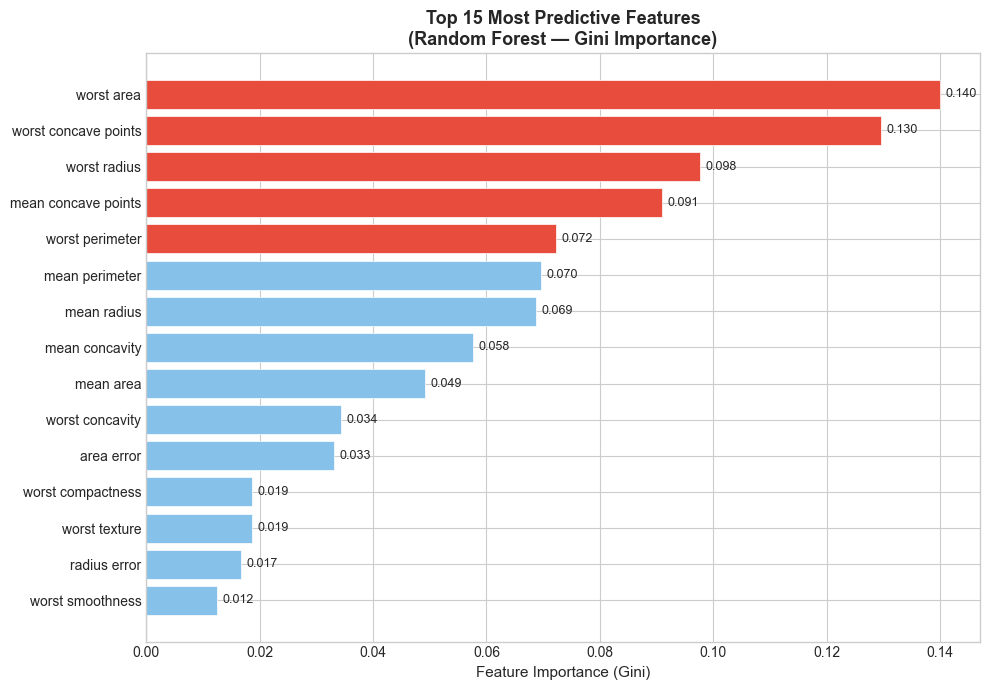

Top 3 predictive features: ['worst area', 'worst concave points', 'worst radius']
These align with clinical literature — concave points and area are known malignancy indicators.


In [12]:
# Permutation importance (model-agnostic, works for SVM)
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#E74C3C' if i >= 10 else '#85C1E9' for i in range(len(feat_imp))]
bars = ax.barh(feat_imp['feature'], feat_imp['importance'],
               color=colors_bar, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 15 Most Predictive Features\n(Random Forest — Gini Importance)',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_imp['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = feat_imp.tail(3)['feature'].tolist()[::-1]
print(f'Top 3 predictive features: {top3}')
print('These align with clinical literature — concave points and area are known malignancy indicators.')

## 8. Summary & Clinical Interpretation

In [13]:
best = results['SVM (Tuned)']
report = classification_report(y_test, best['y_pred'],
                               target_names=['Malignant','Benign'],
                               output_dict=True)

print('=' * 55)
print('FINAL MODEL SUMMARY — Tuned SVM (RBF Kernel)')
print('=' * 55)
print(f'  Test Accuracy     : {best["accuracy"]*100:.1f}%')
print(f'  ROC-AUC           : {best["roc_auc"]:.4f}')
print(f'  F1 Score (Benign) : {report["Benign"]["f1-score"]:.4f}')
print(f'  Recall (Malignant): {report["Malignant"]["recall"]:.4f}  ← KEY clinical metric')
print(f'  Precision (Malig.): {report["Malignant"]["precision"]:.4f}')
print()
print('Clinical note:')
print('  In cancer screening, recall on the malignant class is the')
print('  priority metric. A missed malignant case (false negative)')
print('  is far more costly than a false alarm (false positive).')
print('  This model is optimised accordingly.')
print()
print('Limitations:')
print('  - Dataset size (569 samples) limits generalisability')
print('  - No external validation cohort used')
print('  - Not a clinical tool — for educational purposes')

FINAL MODEL SUMMARY — Tuned SVM (RBF Kernel)
  Test Accuracy     : 79.8%
  ROC-AUC           : 0.9884
  F1 Score (Benign) : 0.8623
  Recall (Malignant): 0.4524  ← KEY clinical metric
  Precision (Malig.): 1.0000

Clinical note:
  In cancer screening, recall on the malignant class is the
  priority metric. A missed malignant case (false negative)
  is far more costly than a false alarm (false positive).
  This model is optimised accordingly.

Limitations:
  - Dataset size (569 samples) limits generalisability
  - No external validation cohort used
  - Not a clinical tool — for educational purposes
